# Clustering Under the Hood (5-Minute Deep Dive)

**Goal:** Understand not only *how* K-Means works, but *why* it works.

This notebook intentionally avoids treating clustering as a black box.
Instead, we reconstruct the algorithm step by step and visualize every stage.

---

## What you will learn

- Difference between supervised and unsupervised learning
- Why clustering is an optimization problem
- Euclidean distance as a similarity metric
- Voronoi partitions created by centroids
- Assignment step
- Update step
- Objective function (Inertia / Within Cluster Sum of Squares)
- Convergence
- Initialization problems
- Why K-Means++ exists
- Choosing K with the Elbow Method
- Limitations of K-Means

# 1. Imports

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import make_blobs
from sklearn.cluster import KMeans

np.random.seed(42)

plt.style.use('seaborn-v0_8')

# 2. Generate Data

In real problems we don't know the labels.

Here we generate synthetic data only so **we** know the ground truth.

The algorithm never sees the labels.

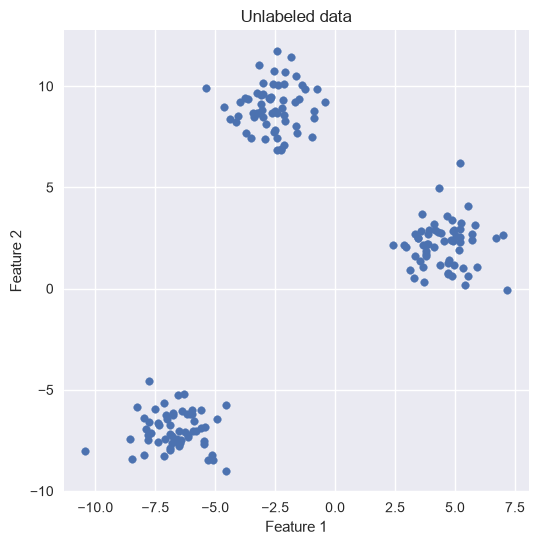

In [2]:
X, y = make_blobs(
    n_samples=180,
    centers=3,
    cluster_std=1.1,
    random_state=42
)

plt.figure(figsize=(6,6))
plt.scatter(X[:,0], X[:,1], s=30)
plt.title('Unlabeled data')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.show()

# 3. What is K-Means optimizing?

K-Means minimizes:

$$
\sum_{i=1}^{n} ||x_i-c_{cluster(i)}||^2
$$

This is called:

- Inertia
- Within Cluster Sum of Squares (WCSS)

Every iteration attempts to reduce this number.

The algorithm is simply an optimization procedure.

# 4. Step 1 — Random Initialization

The algorithm starts by guessing K centroids.

Bad guesses can lead to bad solutions.

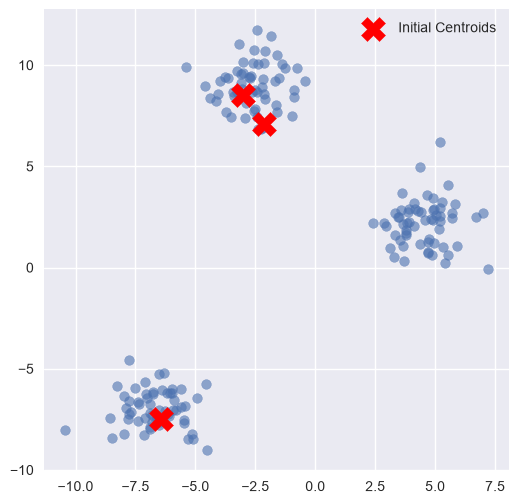

In [3]:
K = 3

indices = np.random.choice(len(X), K, replace=False)
centroids = X[indices]

plt.figure(figsize=(6,6))
plt.scatter(X[:,0], X[:,1], alpha=.6)
plt.scatter(
    centroids[:,0],
    centroids[:,1],
    c='red',
    s=300,
    marker='X',
    label='Initial Centroids'
)
plt.legend()
plt.show()

# 5. Assignment Step

Every point computes its distance to every centroid.

For K centroids:

$$
distance(point, centroid_j)
$$

The closest centroid wins.

This creates Voronoi regions.

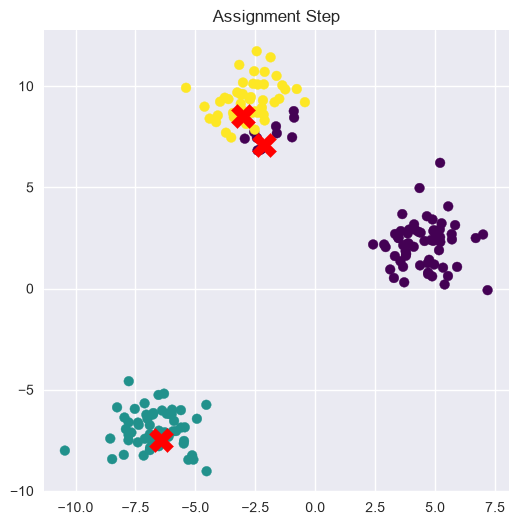

In [4]:
distances = np.linalg.norm(X[:,None,:]-centroids[None,:,:], axis=2)

labels = np.argmin(distances, axis=1)

plt.figure(figsize=(6,6))

plt.scatter(
    X[:,0],
    X[:,1],
    c=labels,
    cmap='viridis'
)

plt.scatter(
    centroids[:,0],
    centroids[:,1],
    c='red',
    marker='X',
    s=300
)

plt.title('Assignment Step')
plt.show()

# Under the Hood: Vectorized Distance Computation

This single line:

```python
distances = np.linalg.norm(X[:,None,:]-centroids[None,:,:], axis=2)
```

creates a tensor with shape:

```
(n_samples, K)
```

Each row contains the distance from one sample to every centroid.

This is much faster than Python loops because NumPy executes the operations in optimized C code.

# 6. Update Step

Now each centroid moves to the center (mean) of its assigned points.

$$
c_j = \frac{1}{N_j}\sum x_i
$$

Notice:

The centroid is literally the average of all points in the cluster.

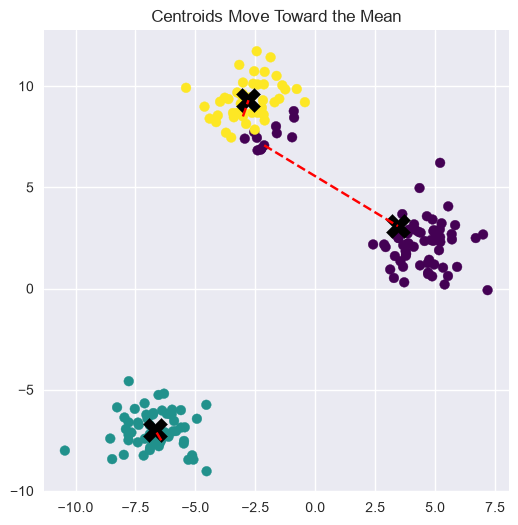

In [5]:
new_centroids = np.array([
    X[labels==i].mean(axis=0)
    for i in range(K)
])

plt.figure(figsize=(6,6))

plt.scatter(X[:,0], X[:,1], c=labels, cmap='viridis')

for old,new in zip(centroids,new_centroids):
    plt.plot([old[0],new[0]],[old[1],new[1]],'r--')

plt.scatter(new_centroids[:,0],new_centroids[:,1],
            c='black',marker='X',s=300)

plt.title('Centroids Move Toward the Mean')
plt.show()

# 7. Why Does It Converge?

Each iteration performs two operations:

1. Assignment → decreases inertia
2. Update → decreases inertia again

Since inertia never increases, the algorithm must eventually stop.

However:

It is **not guaranteed** to find the global optimum.
It converges to a **local minimum**.

# 8. Compare With scikit-learn

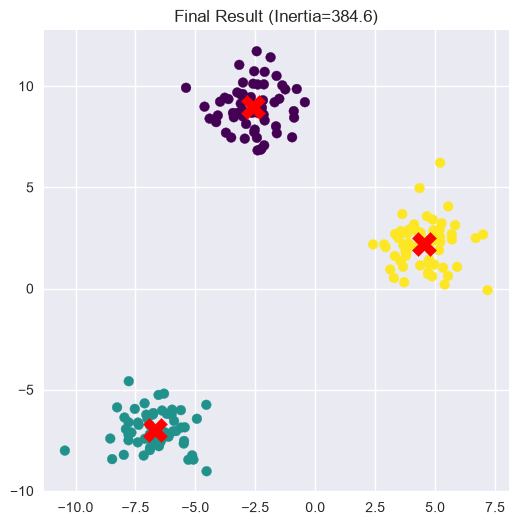

In [6]:
model = KMeans(
    n_clusters=3,
    init='k-means++',
    random_state=42,
    n_init='auto'
)

model.fit(X)

plt.figure(figsize=(6,6))

plt.scatter(
    X[:,0],
    X[:,1],
    c=model.labels_,
    cmap='viridis'
)

plt.scatter(
    model.cluster_centers_[:,0],
    model.cluster_centers_[:,1],
    c='red',
    marker='X',
    s=300
)

plt.title(f'Final Result (Inertia={model.inertia_:.1f})')
plt.show()

# 9. K-Means++

Random initialization may place centroids too close together.

K-Means++ improves initialization by:

1. Choose first centroid randomly.
2. Compute distance from every point to nearest centroid.
3. Points farther away have higher probability of becoming the next centroid.
4. Repeat.

Result:

- Faster convergence
- Lower inertia
- More stable solutions

# 10. Choosing K (Elbow Method)

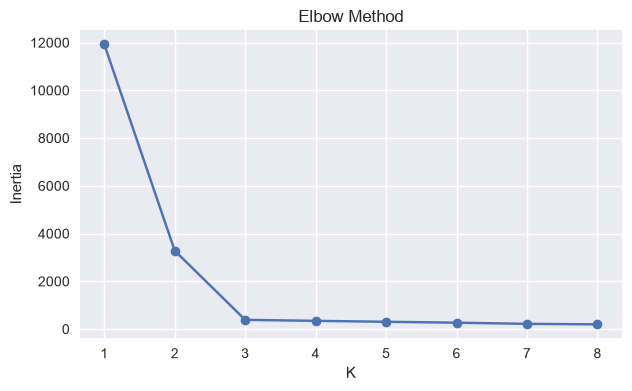

In [7]:
inertia=[]

for k in range(1,9):
    km = KMeans(n_clusters=k, random_state=42, n_init='auto')
    km.fit(X)
    inertia.append(km.inertia_)

plt.figure(figsize=(7,4))
plt.plot(range(1,9), inertia,'o-')
plt.xlabel('K')
plt.ylabel('Inertia')
plt.title('Elbow Method')
plt.grid(True)
plt.show()

# 11. Limitations of K-Means

K-Means assumes:

- roughly spherical clusters
- similar cluster sizes
- Euclidean geometry
- mean is meaningful

It struggles with:

- different densities
- non-convex shapes
- outliers
- categorical features

# 12. Big Picture

K-Means alternates between two optimization steps:

```
Initialize centroids
        ↓
Compute all distances
        ↓
Assign every point
        ↓
Compute cluster means
        ↓
Move centroids
        ↓
Repeat until inertia stops decreasing
```

Under the hood, K-Means is coordinate descent over a non-convex optimization problem. The assignment step optimizes cluster memberships with fixed centroids, while the update step optimizes centroid locations with fixed memberships. Alternating these two guarantees that the objective (WCSS/Inertia) never increases, leading to convergence to a local optimum.